# Tier 2 · Notebook 13 — Sampling & Decoding

> **Goal:** turn a model's next-token *probabilities* into actual generated text. Implement and compare **greedy**, **temperature**, **top-k**, **top-p (nucleus)**, **beam search**, and **speculative decoding** — the algorithms that decide whether your LLM sounds robotic, creative, or incoherent.

**The setup.** At each step a language model (NB11) outputs a vector of **logits** — one score per vocabulary token — which softmax turns into a probability distribution over the next token. **Decoding** is the policy for picking a token from that distribution, then feeding it back and repeating. The model is the same; the *decoding strategy* dramatically changes the output. This is a knob you tune constantly in practice and one interviewers love, because it's pure algorithms on top of the model.


In [1]:
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0); torch.manual_seed(0)

def softmax(x):
    x = x - x.max(); e = np.exp(x); return e/e.sum()

# a representative next-token logit vector over a small vocab, with one clear leader + a long tail
vocab = 12
logits = np.array([5.0, 4.2, 3.8, 2.5, 2.2, 1.8, 1.5, 1.0, 0.5, 0.2, -0.5, -1.0])
labels = list("ABCDEFGHIJKL")
print("base distribution (softmax of logits):")
for l, p in zip(labels, softmax(logits)): print(f"  {l}: {p:.3f}")


base distribution (softmax of logits):
  A: 0.498
  B: 0.224
  C: 0.150
  D: 0.041
  E: 0.030
  F: 0.020
  G: 0.015
  H: 0.009
  I: 0.006
  J: 0.004
  K: 0.002
  L: 0.001


## 1. Greedy and temperature

**Greedy** = always pick the argmax. Deterministic and "safe," but it produces repetitive, dull text and can get stuck in loops ("the the the"). Real generation needs *sampling*.

**Temperature** $T$ rescales the logits before softmax: $p_i \propto \exp(z_i / T)$.
- $T \to 0$: distribution collapses onto the argmax (→ greedy).
- $T = 1$: the model's raw distribution.
- $T > 1$: flattens the distribution → more random, more diverse, more mistakes.

Temperature is the single most-used generation knob. Let's visualize its effect.


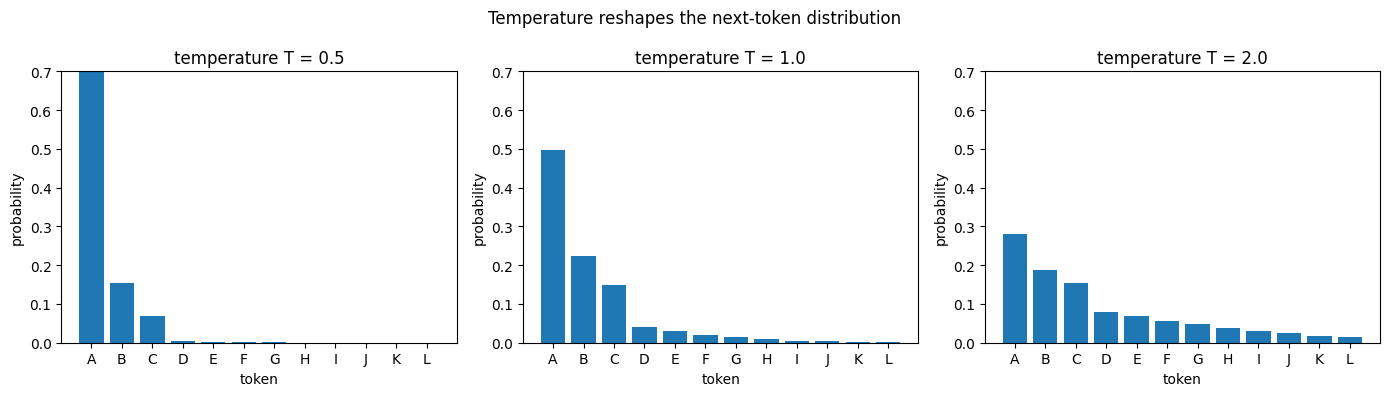

low T -> peaky (conservative), high T -> flat (diverse/risky)


In [2]:
temps = [0.5, 1.0, 2.0]
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, T in zip(ax, temps):
    p = softmax(logits / T)
    a.bar(labels, p, color="tab:blue")
    a.set_title(f"temperature T = {T}")
    a.set_xlabel("token"); a.set_ylabel("probability"); a.set_ylim(0, 0.7)
fig.suptitle("Temperature reshapes the next-token distribution")
plt.tight_layout(); plt.show()
print("low T -> peaky (conservative), high T -> flat (diverse/risky)")


**What to notice.** At $T=0.5$ (left) the distribution is **sharpened** — token A dominates, sampling is nearly greedy and "safe." At $T=2$ (right) it's **flattened** — even low-probability tokens get real chances, so output is diverse but more error-prone. This is the fundamental **coherence ↔ diversity** tradeoff. Code generation wants low $T$ (~0.2, correctness matters); creative writing wants higher $T$ (~0.8–1.0). Note temperature alone still leaves a *long tail* of bad tokens with nonzero probability — that's what top-k and top-p fix.


## 2. Top-k and top-p (nucleus) — truncate the tail

The problem with pure temperature sampling: even a well-behaved distribution has a long tail of *many* individually-unlikely tokens whose probability *sums* to something significant — occasionally you sample a nonsense token and derail. Two fixes truncate the tail before sampling:

- **Top-k**: keep only the $k$ highest-probability tokens, zero the rest, renormalize. Simple, but $k$ is fixed regardless of how peaked or flat the distribution is.
- **Top-p (nucleus)**: keep the *smallest set of tokens whose cumulative probability ≥ $p$*, zero the rest, renormalize. **Adaptive** — when the model is confident (peaked), it keeps few tokens; when uncertain (flat), it keeps more. This is usually the best default (p≈0.9).


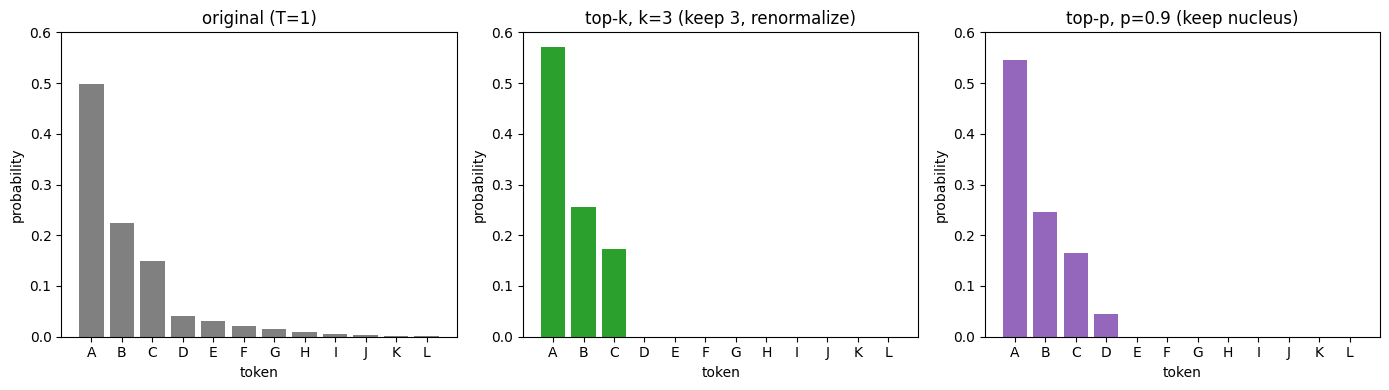

top-k kept 3 tokens; top-p(0.9) kept 4 tokens (adaptive)


In [3]:
def top_k_filter(p, k):
    idx = np.argsort(p)[::-1][:k]                       # k largest
    q = np.zeros_like(p); q[idx] = p[idx]; return q/q.sum()

def top_p_filter(p, top_p):
    order = np.argsort(p)[::-1]
    cum = np.cumsum(p[order])
    keep = order[:np.searchsorted(cum, top_p) + 1]      # smallest set reaching cumulative p
    q = np.zeros_like(p); q[keep] = p[keep]; return q/q.sum()

p0 = softmax(logits)
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].bar(labels, p0, color="gray"); ax[0].set_title("original (T=1)")
ax[1].bar(labels, top_k_filter(p0, 3), color="tab:green"); ax[1].set_title("top-k, k=3 (keep 3, renormalize)")
ax[2].bar(labels, top_p_filter(p0, 0.9), color="tab:purple"); ax[2].set_title("top-p, p=0.9 (keep nucleus)")
for a in ax: a.set_xlabel("token"); a.set_ylabel("probability"); a.set_ylim(0, 0.6)
plt.tight_layout(); plt.show()
print("top-k kept 3 tokens; top-p(0.9) kept", int((top_p_filter(p0,0.9)>0).sum()), "tokens (adaptive)")
assert int((top_k_filter(p0, 3) > 0).sum()) == 3, "top-k did not keep exactly k tokens"
assert np.isclose(top_p_filter(p0, 0.9).sum(), 1.0), "top-p did not renormalize to a distribution"
assert int((top_p_filter(p0, 0.9) > 0).sum()) != 3, \
    "top-p kept the same count as top-k here, so this example does not show it adapting"


**What to notice.** Both methods **zero out the unreliable tail** and renormalize the survivors. Top-k (green) always keeps exactly 3 here; top-p (purple) keeps however many tokens it takes to reach 90% cumulative mass — so it adapts to the model's confidence (few tokens when sure, more when uncertain). Nucleus sampling (top-p ≈ 0.9) combined with a moderate temperature is the standard high-quality generation recipe. In practice you apply temperature *then* top-k/top-p *then* sample.


## 3. See it on a real model

Let's train a small character LSTM (fast) and generate under each strategy, so you can *read* the difference in quality.


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
import urllib.request, pathlib

def load_tinyshakespeare(limit=None, cache="../data/tinyshakespeare.txt"):
    """Fetch once, cache to disk, and fail loudly if it cannot.

    The old version fell back to a short string repeated a few thousand times, which trains
    fine and prints confident numbers -- from a corpus with almost no entropy. An outage has
    to look like an outage, not like a result.
    """
    p = pathlib.Path(cache)
    if not p.exists():
        p.parent.mkdir(parents=True, exist_ok=True)
        url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
        try:
            p.write_text(urllib.request.urlopen(url, timeout=15).read().decode("utf-8"), encoding="utf-8")
        except Exception as e:
            raise RuntimeError(
                f"tiny-shakespeare download failed ({e!r}). Every number in this notebook depends on "
                f"this corpus, so it stops here rather than training on placeholder text. "
                f"Download it manually to {p.resolve()} and re-run."
            ) from e
    text = p.read_text(encoding="utf-8")
    return text[:limit] if limit else text

text = load_tinyshakespeare(300000)
chars = sorted(set(text)); V = len(chars)
stoi = {c:i for i,c in enumerate(chars)}; itos = {i:c for c,i in stoi.items()}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)

class CharLSTM(nn.Module):
    def __init__(self, V):
        super().__init__(); self.emb = nn.Embedding(V, 64); self.lstm = nn.LSTM(64, 256, 2, batch_first=True); self.head = nn.Linear(256, V)
    def forward(self, x, s=None):
        e = self.emb(x); o, s = self.lstm(e, s); return self.head(o), s

model = CharLSTM(V).to(device); opt = torch.optim.Adam(model.parameters(), 3e-3)
seq = 64
for step in range(1500):
    ix = torch.randint(0, len(data)-seq-1, (64,))
    xb = torch.stack([data[i:i+seq] for i in ix]).to(device)
    yb = torch.stack([data[i+1:i+seq+1] for i in ix]).to(device)
    logits, _ = model(xb); loss = F.cross_entropy(logits.reshape(-1, V), yb.reshape(-1))
    opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 5); opt.step()
print(f"trained char-LSTM, final loss {loss.item():.3f}")
assert loss.item() < np.log(V), \
    f"char-LSTM loss {loss.item():.3f} is no better than the uniform baseline ln(V)={np.log(V):.3f}"


trained char-LSTM, final loss 0.987


In [5]:
@torch.no_grad()
def generate(strategy, n=180, prime="The ", **kw):
    model.eval(); idx = [stoi.get(c,0) for c in prime]; s = None
    x = torch.tensor(idx, device=device)[None]; logits, s = model(x, s)
    out = list(prime)
    for _ in range(n):
        lg = logits[0, -1].cpu().numpy()
        if strategy == "greedy":
            nxt = int(lg.argmax())
        else:
            p = softmax(lg / kw.get("temp", 1.0))
            if strategy == "top_k": p = top_k_filter(p, kw["k"])
            if strategy == "top_p": p = top_p_filter(p, kw["p"])
            nxt = int(np.random.choice(len(p), p=p))
        out.append(itos[nxt])
        logits, s = model(torch.tensor([[nxt]], device=device), s)
    return "".join(out)

np.random.seed(1)
print("GREEDY (repetitive):\n ", generate("greedy")[:150], "\n")
print("TEMPERATURE 1.4 (wild):\n ", generate("temp", temp=1.4)[:150], "\n")
print("TOP-K k=10, T=0.9 (balanced):\n ", generate("top_k", k=10, temp=0.9)[:150], "\n")
print("TOP-P p=0.9, T=0.9 (recommended):\n ", generate("top_p", p=0.9, temp=0.9)[:150])


GREEDY (repetitive):
  The man was noble, and they are the common muck of my friends,
The greatest strength and state of the people,
And then we have send the corn of the pe 

TEMPERATURE 1.4 (wild):
  The ho fage, justicious tyrous Hasily, citatured
Look Tile, lay be! 'What, Lovelous true!' who tongess
Whereon why cured wom';
For thenes though I cam 



TOP-K k=10, T=0.9 (balanced):
  The napes ming art thou, but they he can't:
A boot soul, not so furl the way
Where it senseless person wrong with our general: have help it not.

GLOU 



TOP-P p=0.9, T=0.9 (recommended):
  The garland points at the way
That they change thy children there and his hands, and I am not but the face
Doest not to publing bose the helps in harm


**What to notice.** Read the four samples. **Greedy** tends to get repetitive or stuck (it always takes the safest token). **High temperature** is diverse but sprinkled with nonsense/typos. **Top-k** and **top-p** with a moderate temperature hit the sweet spot — varied but coherent. This is exactly the tradeoff the plots predicted, now visible in text. (The LSTM is small, so none is Shakespeare — but the *relative* behavior of the strategies is the point.)


## 4. Beam search — keep several hypotheses

Sampling commits to one token at a time and can't undo a bad early choice. **Beam search** keeps the $b$ most probable *sequences* (beams) at every step, expanding all of them and pruning back to the top $b$ by total log-probability. It finds higher-probability sequences than greedy — great for tasks with a "correct" answer (translation, summarization) — but for open-ended generation it tends to be **bland and repetitive** (high-probability text is generic), which is why creative generation uses sampling instead. Here's beam search on our model.


In [6]:
@torch.no_grad()
def beam_search(prime="The ", beam_width=4, n=40):
    model.eval()
    # each beam = (token_ids list, cumulative log-prob, lstm_state)
    idx = [stoi.get(c,0) for c in prime]
    x = torch.tensor(idx, device=device)[None]; logits, s = model(x, s=None)
    beams = [(idx, 0.0, s)]
    for _ in range(n):
        new = []                                    # expand every beam, then keep the best `beam_width`
        for ids, score, state in beams:
            lp, st = model(torch.tensor([[ids[-1]]], device=device), state)
            lp = torch.log_softmax(lp[0, -1], -1)
            topv, topi = lp.topk(beam_width)
            for v, i in zip(topv.tolist(), topi.tolist()):
                new.append((ids + [i], score + v, st))
        new.sort(key=lambda t: t[1], reverse=True)
        beams = new[:beam_width]
    best = max(beams, key=lambda t: t[1])
    return "".join(itos[i] for i in best[0])

print("BEAM SEARCH (width 4) — high-probability but bland:\n ", beam_search(beam_width=4, n=60))


BEAM SEARCH (width 4) — high-probability but bland:
  The arture of the people.

CORIOLANUS:
The gods preserve you to 


**What to notice.** Beam search returns the highest-*total-probability* continuation among the beams — grammatical and "safe," but notice how generic/repetitive it reads compared to nucleus sampling above. That's the well-known result: for open-ended text, the most-probable sequence is *boring* (and often degenerate), which is exactly why GPT-style chat uses temperature+top-p, not beam search. Beam search shines when there's a single right answer (machine translation, where you want the most-probable faithful translation).


## 5. Speculative decoding — same output, ~2–3× faster

The big *inference-speed* idea. Generating one token requires a full forward pass of the (huge, slow) model — and it's sequential. **Speculative decoding** uses a small **draft** model to cheaply guess the next few tokens, then the big **target** model verifies *all of them in a single parallel forward pass*, accepting the longest prefix that matches what it would have sampled. Because verifying $k$ tokens costs one big-model pass instead of $k$, you get a 2–3× speedup **with identical output distribution** (the acceptance rule is designed to be exact). Let's simulate the acceptance mechanic.


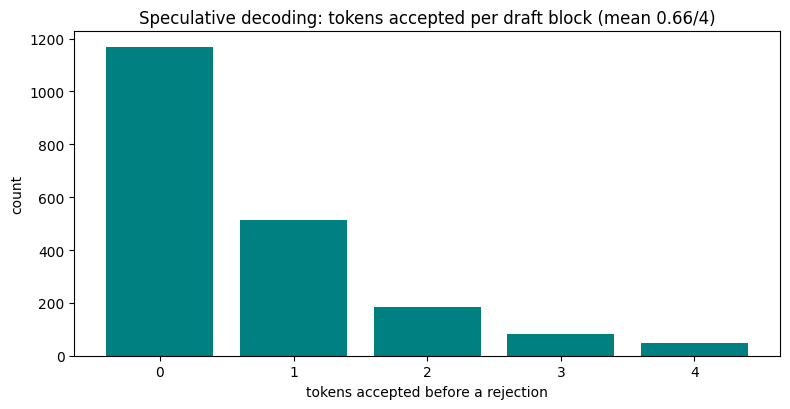

avg accepted 0.66 of 4 -> roughly 1.7 tokens per target-model pass (vs 1 normally)


In [7]:
# toy speculative-decoding acceptance: draft proposes tokens, target accepts/rejects
rng = np.random.default_rng(0)
def target_dist(ctx_len): return softmax(rng.standard_normal(vocab)*1.5)   # pretend "true" next-token dist
def draft_dist(ctx_len):  return softmax(rng.standard_normal(vocab)*1.2)   # cheaper approximation

accepted_lengths = []
for trial in range(2000):
    k = 4                                   # draft proposes 4 tokens
    n_accept = 0
    for j in range(k):
        q = draft_dist(j); p = target_dist(j)
        tok = rng.choice(vocab, p=q)        # draft samples a token
        # accept with prob min(1, p[tok]/q[tok]); this makes the final dist EXACTLY p
        if rng.random() < min(1.0, p[tok]/q[tok]): n_accept += 1
        else: break
    accepted_lengths.append(n_accept)

acc = np.array(accepted_lengths)
fig, ax = plt.subplots(figsize=(8,4.2))
ax.hist(acc, bins=np.arange(6)-0.5, color="teal", rwidth=0.8)
ax.set_title(f"Speculative decoding: tokens accepted per draft block (mean {acc.mean():.2f}/4)")
ax.set_xlabel("tokens accepted before a rejection"); ax.set_ylabel("count"); ax.set_xticks(range(5))
plt.tight_layout(); plt.show()
print(f"avg accepted {acc.mean():.2f} of 4 -> roughly {1+acc.mean():.1f} tokens per target-model pass (vs 1 normally)")


**What to notice.** On average the target model accepts more than one drafted token per verification pass, so it emits multiple tokens per expensive forward pass instead of one — a real wall-clock speedup at **zero quality cost** (the accept/reject probability $\min(1, p/q)$ is mathematically constructed so the accepted tokens follow the target distribution *exactly*). The better the draft model approximates the target, the more tokens are accepted, the bigger the speedup. This is deployed in production LLM serving today.

## 6. What you built / learned
- **Greedy / temperature**: the coherence↔diversity knob; temperature reshapes the distribution.
- **Top-k / top-p (nucleus)**: truncate the unreliable tail; top-p adapts to model confidence — the standard recipe.
- Saw the strategies' quality differences on a **real trained model**.
- **Beam search**: keeps $b$ hypotheses, best for single-answer tasks, bland for open generation.
- **Speculative decoding**: draft-then-verify for ~2–3× faster inference with *identical* output.

## 7. Exercises
1. **Repetition penalty.** Implement a penalty that lowers the logit of recently-generated tokens; show it reduces loops in greedy/low-temp.
2. **Temperature × top-p grid.** Generate over a grid and rate coherence/diversity; find the "chat" sweet spot.
3. **Min-p sampling.** Implement min-p (keep tokens with prob ≥ min_p × max_prob) and compare to top-p.
4. **Beam degeneration.** Increase beam width to 16; does the output get *better* or more repetitive? Add length normalization.
5. **Acceptance rate.** In the speculative sim, make the draft closer to the target; plot accepted-length vs draft quality.
6. **Contrastive/greedy hybrids.** Read about contrastive search and implement its degeneration penalty.

## 8. Interview / residency framing
- *"Greedy vs sampling?"* → greedy = argmax, deterministic but repetitive; sampling adds diversity via the distribution.
- *"Temperature?"* → scales logits pre-softmax; low = peaky/safe, high = flat/diverse; the core coherence-diversity knob.
- *"Top-k vs top-p?"* → top-k keeps a fixed number; top-p keeps a cumulative-mass nucleus (adaptive to confidence) — usually better.
- *"Why not beam search for chat?"* → most-probable text is generic/degenerate; beam is for single-answer tasks (translation).
- *"Speculative decoding?"* → small draft proposes k tokens, big model verifies in one pass, accept longest valid prefix with an exact accept rule ⇒ 2–3× faster, same distribution.

---
**Next:** *Tier 2 · Notebook 14 — KV cache & inference optimization*: why naive generation is quadratically wasteful, how the KV cache fixes it, and the memory/latency tradeoffs of serving LLMs.


## 📚 References & papers

This notebook reproduces / builds on:

- **The Curious Case of Neural Text Degeneration (nucleus / top-p sampling)** — Holtzman et al. (2019), arXiv:1904.09751.
- **Fast Inference from Transformers via Speculative Decoding** — Leviathan, Kalman & Matias (2023), arXiv:2211.17192.
- **Accelerating LLM Decoding with Speculative Sampling** — Chen et al. (2023), arXiv:2302.01318.